# ANALYSE EXPLORATOIRE DE DONNÉES  

Ce notebook vise à produire une analyse exploratoire de données, de raconter l'histoire des données de nexacommerce, ce qui constitueras notre rapport final. L'objectif seras donc :

1.  Nettoyer et normalise les données

2.  Des visualisation pour raconter l'histoire de la données

3.  Identifiez les insights les plus actionnables 

**Objectifs** : *Racontez les données de nexacommerce*

## Chargement des données 

Ici nous importons les données, les biblothèques que nous allons utiliser tout au long de notre notebook ainsi que les configurations.

In [ ]:
from nexacommerce.config import *
from nexacommerce.inspection import inspect_dataset
from datetime import datetime
from scipy.stats import ttest_ind
from plotly.subplots import make_subplots
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

orders = pd.read_csv(ORDERS_FILE, encoding="utf-8", sep=",", low_memory=False) 
order_items = pd.read_csv(ORDER_ITEMS_FILE, encoding="utf-8", sep=',', low_memory=False)
customers = pd.read_csv(CUSTOMERS_FILE, encoding='utf-8', sep=",", low_memory=False )
couriers = pd.read_csv(COURIERS_FILE, encoding="utf-8", sep=",", low_memory=False)

# style pour les rapports
plt.style.use('seaborn-v0_8-whitegrid') # fond clair, grille discrète

# Paramètres globaux pour la cohérence visuelle
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 150,
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.frameon': False,
    'figure.autolayout': True,
})


# Couleurs 
COLORS = {
    'primary': '#2A67A6',
    'secondary': '#F28C28',
    'success': '#1A6B3C',
    'danger': '#8B1A1A',
    'neutral': '#999999',
}

# Palette pour les graphiques multi-catégories
PALETTE = ['#2A67A6','#F28C28','#1A6B3C','#8B1A1A','#4A235A','#C96A10']

## Pipeline de nettoyage 

Ici nous aurons pour but de comprendre les données et enfin de nettoyer ce qui ne vas pas dans la donnée:
 
- normalisation des statuts,

- normalisation des villes,

- normalise les dates,

- correction analytique des montants, 

- déduplication des clients.

In [72]:
# Inspection des valeurs sur orders 
inspection_orders = inspect_dataset(orders)
# Inspection des valeurs sur customers
inspection_customer = inspect_dataset(customers) 

print(display(inspection_customer))
print(display(inspection_orders))

# Doublons des id de orders et téléphone dand customer 
print(f'Doublons complets : {orders.duplicated().sum()}')
print(f'order_id unique: {orders["order_id"].nunique()} / {len(orders)}')
print(f'Doublons numéro téléphone: {customers[customers["phone"].notna()].duplicated(subset="phone", keep=False).sum()}')
print(f'Téléphone unique: {customers["phone"].nunique()} / {len(customers)} ')

# Verification des variantes et des colonnes
for col in ['status', 'city']:
    print(f'\n{col} ({orders[col].nunique()} valeurs uniques):')
    print(orders[col].value_counts(dropna=False).head(10))


for col in ['product_category']:
    print(f'\n{col} ({order_items[col].nunique()} valeurs unique dans order_items)')
    print(order_items[col].value_counts(dropna=False).head(10))
    
# # Distinction des dates   
date_cols = [c for c in orders.columns if "date" in c.lower()]
if not date_cols:
    print("\nAucune colonne contenant 'date'")
else:
    for c in date_cols:
        print(f"\Collone: {c} — Valeur distinctes :", orders[c].nunique(dropna=False))
        print(orders[c].astype(str).str.strip().value_counts(dropna=False))        
        
 
# Nombre doublons de téléphone dans la table Order
doublons = customers[customers['phone'].notna()].duplicated(subset='phone', keep=False)
print(f'\nClients avec doublons téléphone : {doublons.sum()}')       


,Mesure,Value
0,rows,2380
1,cols,7
2,dtypes,"{'customer_id': 'str', 'name': 'str', 'phone':..."
3,missing_counts,"{'customer_id': 0, 'name': 0, 'phone': 0, 'reg..."
4,missing_percentages,"{'customer_id': 0.0, 'name': 0.0, 'phone': 0.0..."
5,columns_with_missing,[loyalty_score]
6,duplicate_count,0
7,duplicate_percentage,0.0
8,unique,"{'customer_id': 2380, 'name': 2204, 'phone': 2..."
9,not_null,"{'customer_id': 2380, 'name': 2380, 'phone': 2..."


None


,Mesure,Value
0,rows,12500
1,cols,12
2,dtypes,"{'order_id': 'int64', 'customer_id': 'str', 'o..."
3,missing_counts,"{'order_id': 0, 'customer_id': 0, 'order_date'..."
4,missing_percentages,"{'order_id': 0.0, 'customer_id': 0.0, 'order_d..."
5,columns_with_missing,"[delivery_time_min, total_amount_xaf, product_..."
6,duplicate_count,0
7,duplicate_percentage,0.0
8,unique,"{'order_id': 12500, 'customer_id': 2678, 'orde..."
9,not_null,"{'order_id': 12500, 'customer_id': 12500, 'ord..."


None
Doublons complets : 0
order_id unique: 12500 / 12500
Doublons numéro téléphone: 144
Téléphone unique: 2308 / 2380 

status (17 valeurs uniques):
status
livré        7499
en_retard    2429
annulé        978
en_cours      286
Livré         261
livre         144
LIVRE         135
En_retard     131
en retard     119
Annulé         73
Name: count, dtype: int64

city (14 valeurs uniques):
city
Douala      1311
douala      1309
Douala      1293
douala      1277
DOUALA      1232
Yaoundé      845
Yaoundé      839
yaounde      833
Yaounde      812
YAOUNDE      806
Name: count, dtype: int64

product_category (10 valeurs unique dans order_items)
product_category
Épicerie          5870
Restauration      4074
Produits frais    3608
Boissons          3445
Électronique      2922
Pharmacie         2836
Cosmétiques       2346
Hygiène           2335
Vêtements         1774
Papeterie         1765
Name: count, dtype: int64
\Collone: order_date — Valeur distinctes : 11194
order_date
14-03-2025          

## Normalisation ds données 

La cellule précedente nous montre des variations de ligne et de colonne sur la table ordes et customers :

- 17 variantes de statut plus ou moins identique avec aucune ligne vides,

- 14 Valeur de ville plus ou moins identifque et aucune ligne vides,

- Normalisation des dates,

- 38 valeur de product category qui sont identiques mais avons des noms plus ou moins identiques et des valeurs dont je vais remplacer en joinant order_items,  

- Des valeurs null à loyalty_score pour la table customer que je vais remettre à 0 plus cohérent et supérieur à 100 je ramene à 100,     

- Des montants négatifs que je vais mettre en valeur absolute, 

- Des valeurs nulle à delivery_time_min de la table orders que je vais inputer par la médianne.

- Les montants sont en float ramener dans un type int.

### Normalisation des données

#### Normalisation des status

In [73]:
def status_normalise(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip().lower()
    if value in {"LIVRE", "livre", "livré"}:
        return "delivered"
    if value in {"en_retard", "en retard", "retard", "En_retard", "EN_RETARD"}:
        return "late"
    if value in {"annule", "ANNULE",'annulé'}:
        return "cancelled"
    if value in {"en_cours", "en cours","En_cours"}:
        return "in_progress"
    return value.strip().lower().capitalize()

#### Normalisation des villes

In [74]:
def city_normalise(value):
    if pd.isna(value):
        return np.nan
    if value in {"Yaoundã©","Yaoundã©","YaoundÃ©","Yaoundã©","Yaounde",'yaounde'}:
        return "Yaoundé"
    value = str(value).strip().lower()
    return value.capitalize()    

In [75]:
display(orders)

,order_id,customer_id,order_date,delivery_time_min,status,total_amount_xaf,city,quartier,product_category,courier_id,order_hour,order_day_of_week
0,100000,CUST11954,2024-06-07 14:31:00,44.7,livré,15444.0,YAOUNDE,Biyem-Assi,NaN,47,14,Friday
1,100001,CUST11317,2024/04/20 18:56,53.9,livré,16188.0,Yaounde,Messa,NaN,32,18,Saturday
2,100002,CUST17374,2024-07-10 17:37:00,260.7,en_retard,11497.0,Douala,Bonabéri,restauration,32,17,Wednesday
3,100003,CUST10224,2023-03-29 07:48:00,253.8,en_retard,20301.0,Yaounde,Nlongkak,EPICERIE,22,7,Wednesday
4,100004,CUST11846,29/12/2024 08:35,66.5,livré,15639.0,yaounde,Bastos,NaN,30,8,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...
12495,112495,CUST11295,22/05/2024 19:42,202.8,EN_RETARD,39113.0,bafoussam,Mossap,Vêtements,28,19,Wednesday
12496,112496,CUST11910,2023/02/07 18:26,41.4,livré,4776.0,BAFOUSSAM,Lekie,NaN,21,18,Tuesday
12497,112497,CUST11847,06 May 2023,50.3,livré,50750.0,DOUALA,Bonabéri,pharmacie,35,9,Saturday
12498,112498,CUST10517,05/10/2023 13:19,10.1,annulé,18000.0,Douala,Makepe,Restauration,33,13,Thursday


#### Normalisation des dates


In [76]:
# Type de formats constater
DATE_FORMATS = [
    "%Y-%m-%d %H:%M:%S",
    "%Y/%m/%d %H:%M",
    "%d/%m/%Y %H:%M",
    "%d-%m-%Y %H:%M",    
    "%Y-%m-%d",
    "%Y/%m/%d",
    "%d/%m/%Y",
    "%d-%m-%Y",
    "%d %B %Y",
    "%m/%d/%Y",
    "%m-%d-%Y",    
    "%m/%d/%Y %H:%M",
]  

# Fonction normalisation
def date_normalise(value):
    if pd.isna(value):
        return pd.NaT 
    
    value = str(value).strip()
    for fmt in DATE_FORMATS:
        try:
            return pd.to_datetime(datetime.strptime(value, fmt))
        except ValueError:
            continue

    return pd.NaT 

#### Normalisation des numeros de teléphone de la table customers

In [77]:
def normalise_phone(phone):
    if pd.isna(phone): 
        return None
    
    digits = re.sub(r'\D', '', str(phone))
    
    if digits.startswith('237') and len(digits) == 12:
        digits = digits[3:]
        
    if len(digits) == 9 and digits[0] in ('6', '2'):
        return digits
    return None 

#### Imputation à la médiane de delivery_time_min

Ici nous ramenons les valeurs qui sont nul à la mediane

In [78]:
médiane_durée = orders['delivery_time_min'].median()
print(f'Médiane durée : {médiane_durée:.1f} min')
orders['delivery_time_min'] = orders['delivery_time_min'].fillna(médiane_durée)

Médiane durée : 45.7 min


#### Ramener les montants du type float au type float

In [79]:
orders['total_amount_xaf'] = orders['total_amount_xaf'].abs()

customers['registration_date'] = pd.to_datetime(customers['registration_date'], errors="coerce")

#### Violation 2NF supression de la table catégories dans orders

In [80]:
orders = orders.drop(columns=['product_category'])

#### Correction des totals amount

In [81]:
# calculer la somme par order_id dans order_items
items_sum = order_items.dropna(subset=["order_id", "line_total_xaf"]).copy()

# Mettre en numerique
items_sum["line_total_xaf"] = pd.to_numeric(items_sum["line_total_xaf"], errors="coerce")

sum_per_order = items_sum.groupby("order_id", as_index=True)["line_total_xaf"].sum().rename("sum_line_total_xaf")

orders = orders.merge(sum_per_order, left_on="order_id", right_index=True, how="left")

# # déplacer/renommer la colonne dans orders["total_amount_xaf"]
orders["total_amount_xaf"] = orders["sum_line_total_xaf"].fillna(0)
# orders.drop(columns=["sum_line_total_xaf"], inplace=True)
del orders['sum_line_total_xaf']

display(orders)


,order_id,customer_id,order_date,delivery_time_min,status,total_amount_xaf,city,quartier,courier_id,order_hour,order_day_of_week
0,100000,CUST11954,2024-06-07 14:31:00,44.7,livré,7594.0,YAOUNDE,Biyem-Assi,47,14,Friday
1,100001,CUST11317,2024/04/20 18:56,53.9,livré,227.0,Yaounde,Messa,32,18,Saturday
2,100002,CUST17374,2024-07-10 17:37:00,260.7,en_retard,10159.0,Douala,Bonabéri,32,17,Wednesday
3,100003,CUST10224,2023-03-29 07:48:00,253.8,en_retard,17776.0,Yaounde,Nlongkak,22,7,Wednesday
4,100004,CUST11846,29/12/2024 08:35,66.5,livré,1318.0,yaounde,Bastos,30,8,Sunday
...,...,...,...,...,...,...,...,...,...,...,...
12495,112495,CUST11295,22/05/2024 19:42,202.8,EN_RETARD,5292.0,bafoussam,Mossap,28,19,Wednesday
12496,112496,CUST11910,2023/02/07 18:26,41.4,livré,2298.0,BAFOUSSAM,Lekie,21,18,Tuesday
12497,112497,CUST11847,06 May 2023,50.3,livré,26402.0,DOUALA,Bonabéri,35,9,Saturday
12498,112498,CUST10517,05/10/2023 13:19,10.1,annulé,1820.0,Douala,Makepe,33,13,Thursday


#### Loyalty_score ramener à 100 et mettre à 0 

In [ ]:
abérantes = (customers['loyalty_score'] > 100).sum()
print(f'\nNombre de valeurs supérieur à 100 : {abérantes}')

customers['loyalty_score'] = customers['loyalty_score'].clip(lower=0, upper=100)

#Médianne loyalty_score
customer_mean = customers['loyalty_score'].mean() 

# Mettre les loyalty score 0 à la médianne
customers['loyalty_score'] = customers['loyalty_score'].fillna(customer_mean)


Nombre de valeurs supérieur à 100 : 107


#### Déduplication des clients



In [83]:
customers_dup = (
    customers
    .sort_values(["phone", "registration_date"])
    .drop_duplicates(subset=["phone"], keep="first")
    .copy()
)

print("Customers before dedup:", customers.shape[0])
print("Customers after dedup :", customers_dup.shape[0])
print(f"FInal { customers.shape[0] - customers_dup.shape[0]}")


Customers before dedup: 2380
Customers after dedup : 2308
FInal 72


### Application des normalisation sur les différentes tables

In [85]:
orders['status']  = orders['status'].map(status_normalise)
orders['city'] = orders['city'].map(city_normalise)
orders['order_date'] = orders['order_date'].map(date_normalise)
customers['phone'] = customers['phone'].map(normalise_phone) 

### Verification des données correcte

In [86]:
# Vérification des villes des status des categories
for col in ['status', 'city']:
    print(f'\n{col} ({orders[col].nunique()} valeurs uniques):')
    print(orders[col].value_counts(dropna=False).head(10))

for col in ['product_category']:
    print(f'\n{col} ({order_items[col].nunique()} valeurs uniques):')
    print(order_items[col].value_counts(dropna=False).head(10))
    
# Doublons par téléphone
doublons = customers[customers['phone'].notna()].duplicated(subset='phone', keep=False)
print(f'\nClients avec doublons téléphone : {doublons.sum()}')  
print(customers['phone'].head())

# Garder un seul enregistrement par téléphone (le plus récent)
customers_dedup = (customers[customers['phone'].notna()]
.sort_values('registration_date', ascending=False)
.drop_duplicates(subset='phone', keep='first')
)  



# Valeur de total_amount_xaf
print(orders.loc[0:4, 'total_amount_xaf'])

print(inspection_orders)
print(inspection_customer)


status (4 valeurs uniques):
status
Delivered      8103
Late           2802
Cancelled      1170
In_progress     425
Name: count, dtype: int64

city (3 valeurs uniques):
city
Douala       6422
Yaoundé      4135
Bafoussam    1943
Name: count, dtype: int64

product_category (10 valeurs uniques):
product_category
Épicerie          5870
Restauration      4074
Produits frais    3608
Boissons          3445
Électronique      2922
Pharmacie         2836
Cosmétiques       2346
Hygiène           2335
Vêtements         1774
Papeterie         1765
Name: count, dtype: int64

Clients avec doublons téléphone : 464
0    653091709
1    638270233
2          NaN
3    688339168
4    660015814
Name: phone, dtype: str
0     7594.0
1      227.0
2    10159.0
3    17776.0
4     1318.0
Name: total_amount_xaf, dtype: float64
                 Mesure                                              Value
0                  rows                                              12500
1                  cols                  

## Visualisation 

Ici nous devrons mettre à disposition des visualisation qui porteront sur : 

- l'evolution temporelle du volume de commandes

- La répartition géographique des performances 

- Le profil de clients actifs contre ceux inactifs

- L'analyse de crénaux horaires

### Montrons l'évolution du chiffre d'affaire par mois

In [92]:

status_invalides = ['cancelled', 'in_progress' ]
df_filtered = orders[~orders['status'].str.lower().isin(status_invalides)].copy()



df_filtered['order_date'] = pd.to_datetime(df_filtered['order_date'])

monthly_finance = (df_filtered.groupby(df_filtered['order_date'].dt.to_period('M'))
                   .agg({
                       'total_amount_xaf': 'sum', 
                       'order_id': 'count'
                        })
                   .reset_index())

monthly_finance['order_date'] = monthly_finance['order_date'].dt.to_timestamp()
monthly_finance.columns = ['Mois', 'Chiffre_Affaires', 'Nombre_Commandes']

fig = px.area(
    monthly_finance, 
    x='Mois', 
    y='Chiffre_Affaires',
    title="Évolution Mensuelle du Chiffre d'Affaires (Commandes Validées)",
    markers=True,
    text=None, 
    labels={'Chiffre_Affaires': 'CA (FCFA)', 'Mois': 'Période'},
    template="plotly_white"
)

fig.update_traces(
    line_color="#E4CA36", 
    line_width=2,
    marker=dict(size=5, color='#E9370B', symbol='circle'),
    hovertemplate="<b>Mois:</b> %{x|%B %Y}<br><b>CA:</b> %{y:,.0f} FCFA<extra></extra>"
)

fig.update_layout(
    xaxis_title="Mois",
    yaxis_title="Chiffre d'Affaires (XAF)",
    hovermode="x unified" 
)

fig.show()

#### Commentaire

Cette visualisation permet de voir la dynamique de l'activité dans le temps. Elle aide à repérer les phases d'accélération, les creux d'activité et l'éventuelle saisonnalité du volume de commande. Nous constatons que nous avons eu une reduction enorme du nombre de commande au niveau du mois de février en 2025, les commandes on drastiquement diminuer. 

### Chiffre d'affaire de l'entreprise

In [93]:
# Calcul du CA Total encaissé
ca_total = orders[orders['status'].isin(['delivered', 'late'])]['total_amount_xaf'].sum()

print(f"Chiffre d'Affaires Total : {ca_total:,.0f} XAF")

# Chiffre d'affaire par mois
ca_mensuel = (
    orders[orders['status'].isin(['delivered', 'late'])]
    .groupby(orders['order_date'].dt.to_period('M'))['total_amount_xaf']
    .sum()
    .reset_index()
)
ca_mensuel['order_date'] = ca_mensuel['order_date'].dt.to_timestamp()

ca_ville = orders[orders['status'].isin(['delivered', 'late'])].groupby('city')['total_amount_xaf'].sum().sort_values()

fig_ville = px.bar(
    ca_ville, 
    orientation='h', 
    title="Répartition du CA par Ville au Cameroun",
    color=ca_ville.values,
    color_continuous_scale='Viridis'
)
fig_ville.show()


# Taux d'evolution de l'entreprise

ca_mensuel['evolution'] = ca_mensuel['total_amount_xaf'].pct_change() * 100
ca_mensuel['color'] = ca_mensuel['evolution'].apply(lambda x: '#2ecc71' if x >= 0 else '#e74c3c')

fig = go.Figure()

fig.add_trace(go.Bar(
    x=ca_mensuel['order_date'],
    y=ca_mensuel['evolution'],
    marker_color=ca_mensuel['color'],
    text=ca_mensuel['evolution'].round(1).astype(str) + '%',
    textposition='auto',
    name='Évolution MoM'
))

fig.update_layout(
    title="Taux de Croissance Mensuel (%)",
    xaxis_title="Mois",
    yaxis_title="Variation du CA (%)",
    template="plotly_white"
)

fig.show()

Chiffre d'Affaires Total : 0 XAF


### Évolution du chiffre d'affaire

In [33]:
# Recupe des bon status 
orders_sorted = orders[orders['status'].isin(['delivered', 'late','cancelled'])].sort_values('order_date')

# Calculer la somme cumulée
orders_sorted['revenue_cumule'] = orders_sorted['total_amount_xaf'].cumsum()

total_final = orders_sorted['revenue_cumule'].iloc[-1]
orders_sorted['percent_of_total'] = (orders_sorted['revenue_cumule'] / total_final) * 100

# Linec
fig = px.line(
    orders_sorted, 
    x='order_date', 
    y='revenue_cumule',
    title='Trajectoire de Croissance de NexaCommerce (Revenu Cumulé)',
    custom_data=['percent_of_total', 'total_amount_xaf'],
    labels={'revenue_cumule': 'Total encaissé (XAF)', 'order_date': 'Temps'},
    template="plotly_white"
)

# popUp
fig.update_traces(
    line=dict(width=3, color='#2ecc71'),
    fill='tozeroy',
    hovertemplate="<br>".join([
        "<b>Date:</b> %{x}",
        "<b>CA Cumulé:</b> %{y:,.0f} XAF",
        "<b>Montant Commande:</b> %{customdata[1]:,.0f} XAF",
        "<b>Progression Totale:</b> %{customdata[0]:.2f}%", 
        "<extra></extra>" 
    ])
)

fig.update_layout(
    hovermode="x unified",
    yaxis_tickformat=',.0f' 
)

fig.show()

#### Interpretation
Le graphique nous montre l'evolution du chiffre d'affaire de la startup. 

### Répartion du Volume de commande

In [34]:
# recuperer les valeurs
orders['month'] = orders['order_date'].dt.to_period('M').dt.to_timestamp()


stats_by_status = orders.groupby(['month', 'status']).agg({
    'total_amount_xaf': 'sum',
    'order_id': 'count'
}).reset_index()


fig = make_subplots(specs=[[{"secondary_y": True}]])


list_status = orders['status'].unique()

for status in list_status:
    df_temp = stats_by_status[stats_by_status['status'] == status]
    
   
    fig.add_trace(
        go.Scatter(x=df_temp['month'], y=df_temp['total_amount_xaf'], 
                   name=f"CA - {status}", mode='lines+markers', fill='tozeroy',
                   visible=False),
        secondary_y=False,
    )
    
    
    fig.add_trace(
        go.Bar(x=df_temp['month'], y=df_temp['order_id'], 
               name=f"Volume - {status}", opacity=0.5,
               visible=False),
        secondary_y=True,
    )

buttons = []
for i, status in enumerate(list_status):
    
    visibility = [False] * (len(list_status) * 2)
    visibility[i*2] = True
    visibility[i*2 + 1] = True
    
    buttons.append(dict(
        method="update",
        label=status.capitalize(),
        args=[{"visible": visibility},
              {"title": f"Analyse : {status.capitalize()}"}]
    ))


fig.data[0].visible = True
fig.data[1].visible = True


fig.update_layout(
    updatemenus=[dict(active=0, buttons=buttons, x=0, y=1.15, xanchor="left", yanchor="top")],
    title_text="Pilotage NexaCommerce : Revenus vs Volume",
    template="plotly_white",
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.update_yaxes(title_text="<b>CA</b> (XAF)", secondary_y=False)
fig.update_yaxes(title_text="<b>Nombre de Commandes</b>", secondary_y=True)

fig.show()

#### Interprétation
Le graphique ci-dessus nous montre l'evolution des commandes et du chiffres d'affaires au cours des mois. Une hausse des commandes ne traduit pas toujours une hausse proportionnelle au revenu. 

### Profils clients actifs vs inactifs

In [35]:
# count les customers distincts
order_counts = orders['customer_id'].value_counts()


def segment_customer(customer_id):
    count = order_counts.get(customer_id, 0)
    return 'Actif ' if count >= 3 else 'Inactif / Occasionnel'

customers['profile'] = customers['customer_id'].map(segment_customer)


counts = customers['profile'].value_counts()
total_customers = len(customers)
nb_actifs = (order_counts >= 3).sum()
nb_inactifs = len(customers) - nb_actifs

colors = ["#2b8cbe", "#ee0f0f"] 

label_actif = f"Actifs : {nb_actifs}"
label_inactif = f"Inactifs : {nb_inactifs}"


fig = go.Figure(data=[go.Pie(
    labels=[label_actif, label_inactif], 
    values=[nb_actifs, nb_inactifs],
    hole=.6,
    marker=dict(colors=colors, line=dict(color="#FFFFFF", width=2)),
    textinfo='percent+label',
    hoverinfo='label+value+percent',
    pull=[0.1, 0] 
)])

fig.update_layout(
    title_text="Profils des clients - Nexacommerce",
    annotations=[dict(
        text=f'CLIENTS<br>{total_customers}', 
        x=0.5, y=0.5, font_size=20, showarrow=False, font_family="Arial Black"
    )],
    template="plotly_white",
    showlegend=True
)

fig.show()

#### Interpretation

Ce graphique nous presentement simplement le nombre client actif et inactifs que nous avons dans notre BD. Avoir une majorité de client actif signifirait une fidélisation des clients sur les services de nexaCommerce.  Les clients actifs qui ont un taux de comandes superieur a celui des inactifs

### Performances géographiques

In [88]:
Nbgr = orders.groupby("city").apply(lambda x: (x['status'] == 'late').sum())

display(Nbgr)  

city
Bafoussam    0
Douala       0
Yaoundé      0
dtype: int64

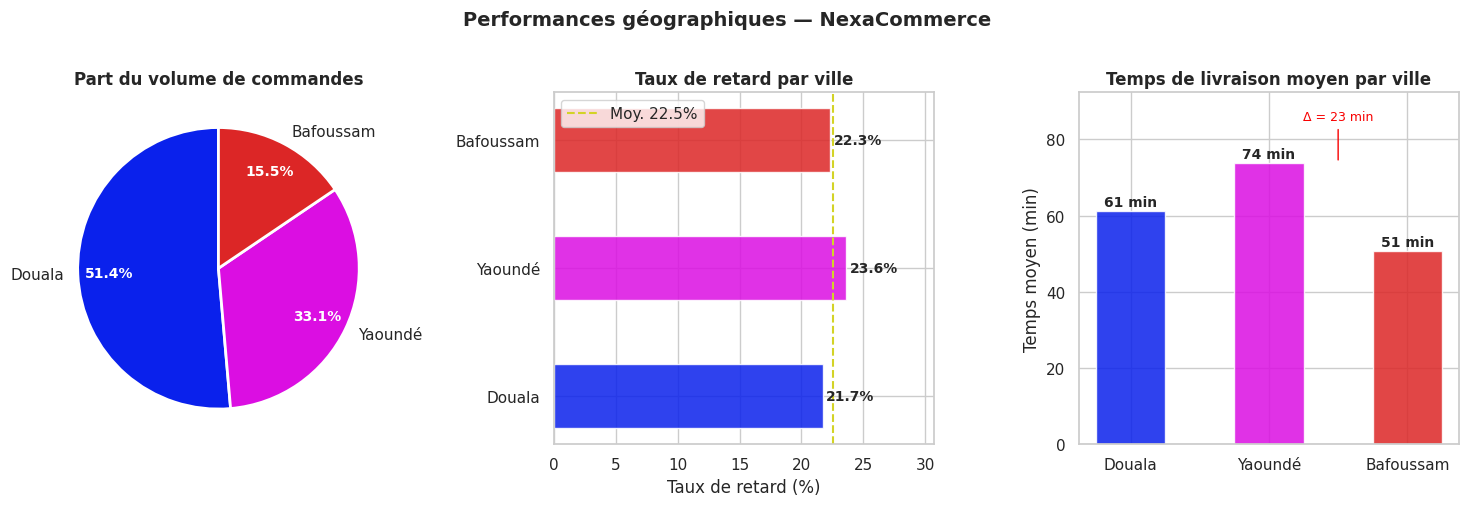

In [207]:
cities = ["Douala", "Yaoundé", "Bafoussam"]

COLORS = {
    "Douala":     "#0A21EC",
    "Yaoundé":    "#DB0EE2",
    "Bafoussam":  "#DC2626",
    "neutral" : "#D3D326",
    "danger": "#F80101"
}

city_colors = [COLORS[c] for c in cities]

city_stats = (
    orders
    .groupby("city")
    .agg(
        orders       = ("order_id",          "count"),
        revenue      = ("total_amount_xaf",  "sum"),
        avg_basket   = ("total_amount_xaf",  "mean"),
        late_rate    = ("status",      lambda x: (x == "late").mean() * 100),
        avg_delivery = ("delivery_time_min", "mean"),
    )
    .loc[cities]
    .round(1)
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
2
ax = axes[0]
wedges, texts, autotexts = ax.pie(
    city_stats["orders"],
    labels=cities,
    colors=city_colors,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.78,
    wedgeprops=dict(edgecolor="white", linewidth=2),
)
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight("bold"); at.set_color("white")
ax.set_title("Part du volume de commandes", fontweight="bold")


ax2 = axes[1]
bars = ax2.barh(cities, city_stats["late_rate"], color=city_colors,
                height=0.5, alpha=0.85)
for bar, val in zip(bars, city_stats["late_rate"]):
    ax2.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
             f"{val:.1f}%", va="center", fontsize=10, fontweight="bold")
ax2.axvline(city_stats["late_rate"].mean(), color=COLORS["neutral"],
            lw=1.5, ls="--", label=f"Moy. {city_stats['late_rate'].mean():.1f}%")
ax2.set_xlabel("Taux de retard (%)")
ax2.set_title("Taux de retard par ville", fontweight="bold")
ax2.set_xlim(0, city_stats["late_rate"].max() * 1.3)
ax2.legend()


ax3 = axes[2]
bars3 = ax3.bar(cities, city_stats["avg_delivery"], color=city_colors,
                width=0.5, alpha=0.85)
for bar, val in zip(bars3, city_stats["avg_delivery"]):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"{val:.0f} min", ha="center", va="bottom",
             fontsize=10, fontweight="bold")
ax3.set_ylabel("Temps moyen (min)")
ax3.set_title("Temps de livraison moyen par ville", fontweight="bold")
ax3.set_ylim(0, city_stats["avg_delivery"].max() * 1.25)


diff = city_stats.loc["Yaoundé", "avg_delivery"] - city_stats.loc["Bafoussam", "avg_delivery"]
ax3.annotate(f"Δ = {diff:.0f} min",
             xy=(1.5, city_stats.loc["Yaoundé", "avg_delivery"]),
             xytext=(1.5, city_stats["avg_delivery"].max() * 1.15),
             ha="center", fontsize=9, color=COLORS["danger"],
             arrowprops=dict(arrowstyle="-", color=COLORS["danger"]))

fig.suptitle("Performances géographiques — NexaCommerce", fontsize=14,
              fontweight="bold", y=1.01)
plt.tight_layout()
fig.savefig( "../reports/EDA/geo_performances.png", bbox_inches="tight", dpi=150)
plt.show()

### Interpretation
Nous avons un graphique ci dessus qui regroupe les performances par ville, les temps de livraison, volume de commande, tauz de retard regrouper par ville. Aisin nous pouvoir voir avec le graphique que Douala est la ville a plus importante    

### Chiffre d'affaire par catégorie de produit

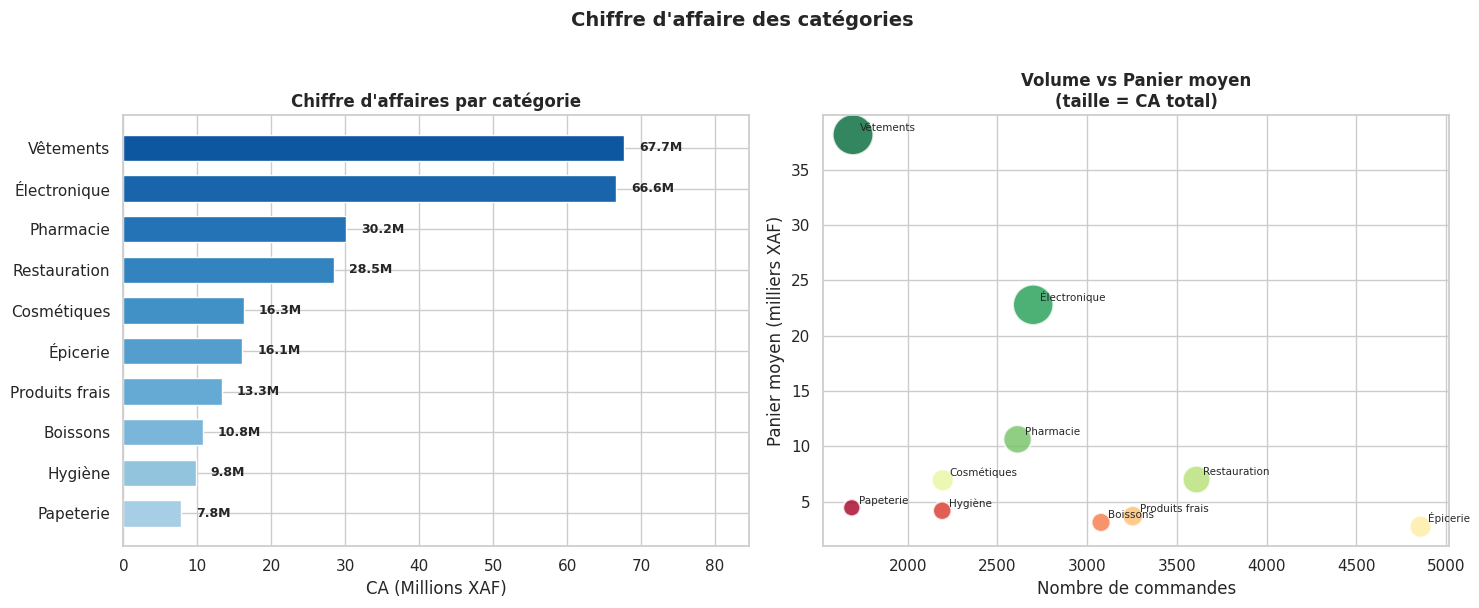

In [ ]:
cat_stats = (
    order_items
    .dropna(subset=["product_category"])
    .groupby("product_category", as_index=True)
    .agg(
        orders=("order_id", "nunique"),            
        revenue=("line_total_xaf", "sum"),        
        avg_basket=("line_total_xaf", "mean"),    
    )
    .sort_values("revenue", ascending=True)
)


fig, axes = plt.subplots(1, 2, figsize=(15, 6))


ax = axes[0]
colors_cat = plt.cm.Blues(np.linspace(0.35, 0.85, len(cat_stats)))
bars = ax.barh(cat_stats.index, cat_stats["revenue"] / 1e6,
               color=colors_cat, height=0.65, edgecolor="white")
for bar, val in zip(bars, cat_stats["revenue"] / 1e6):
    ax.text(val + 0.03 * cat_stats["revenue"].max() / 1e6,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}M", va="center", fontsize=9, fontweight="bold")
ax.set_xlabel("CA (Millions XAF)")
ax.set_title("Chiffre d'affaires par catégorie", fontweight="bold")
ax.set_xlim(0, cat_stats["revenue"].max() / 1e6 * 1.25)



ax2 = axes[1]
sizes = cat_stats["revenue"] / cat_stats["revenue"].max() * 800 + 60
sc = ax2.scatter(
    cat_stats["orders"],
    cat_stats["avg_basket"] / 1000,
    s=sizes,
    c=np.arange(len(cat_stats)),
    cmap="RdYlGn",
    alpha=0.8,
    edgecolors="white",
    linewidth=1.5,
)


for cat, row in cat_stats.iterrows():
    ax2.annotate(
        cat,
        (row["orders"], row["avg_basket"] / 1000),
        fontsize=7.5,
        xytext=(5, 3),
        textcoords="offset points",
    )
ax2.set_xlabel("Nombre de commandes")
ax2.set_ylabel("Panier moyen (milliers XAF)")
ax2.set_title("Volume vs Panier moyen\n(taille = CA total)", fontweight="bold")

fig.suptitle("Chiffre d'affaire des catégories", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
fig.savefig("../reports/EDA/CA_categories_produits.png", bbox_inches="tight", dpi=150)
plt.show()

### Interpretation
Cette figure nous montre les chiffres d'affaire generer par les produits.  

### Livreurs les plus performants

In [ ]:
 # On calcule simultanément la moyenne de temps et le taux de retard

courier_stats = (

orders.merge(couriers, on="courier_id", how="left")

.groupby(["courier_id", "name"])

.agg(

temps_moyen=('delivery_time_min', 'mean'),

taux_retard=('status', lambda x: (x == 'late').mean() * 100),

total_commandes=('order_id', 'count')

)

.reset_index()

)



top_10_fastest = courier_stats.sort_values("temps_moyen", ascending=True).head(10)



fig = px.bar(

top_10_fastest,

x="name",

y="temps_moyen",

color="taux_retard",

color_continuous_scale="RdYlGn_r",

title="Top 10 Livreurs : Rapidité vs Taux de Retard",

labels={

"name": "Livreur",

"temps_moyen": "Temps Moyen (min)",

"taux_retard": "% de Retard"

},

custom_data=["taux_retard", "total_commandes"]

)


# PopUp

fig.update_traces(

hovertemplate="<br>".join([

"<b>Livreur:</b> %{x}",

"<b>Temps Moyen:</b> %{y:.1f} min",

"<b>Taux de Retard:</b> %{customdata[0]:.1f}%",

"<b>Total Livraisons:</b> %{customdata[1]}",

"<extra></extra>"

])

)


fig.show() 

#### Interpretation 
Le graphique nous présente les livreurs les plus perfomants.


### Temps moyen de livraison par jour


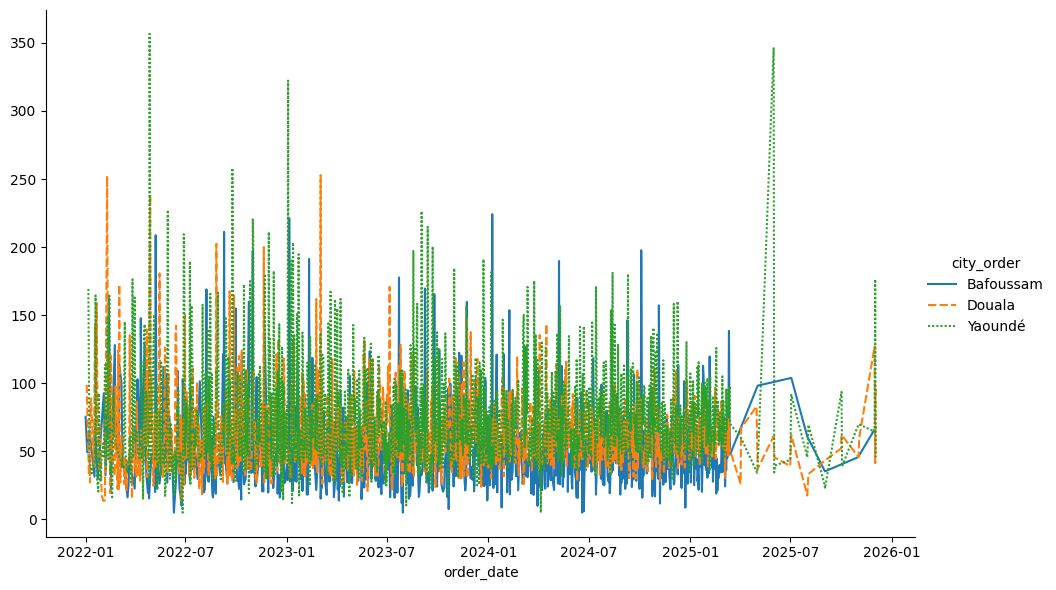

In [57]:
analysis = orders.merge(
    customers[['customer_id','name','city','loyalty_score','profile']],
    on='customer_id',
    how='left',
    suffixes=('_order','_cust')    
)

daily = analysis.groupby([analysis['order_date'].dt.date, 'city_order'])['delivery_time_min'].mean().reset_index()
daily_wide = daily.pivot(index='order_date', columns='city_order', values='delivery_time_min')
sns.relplot(data=daily_wide, kind='line', height=6, aspect=1.6)

#### Interprétation
Le graphique suivant nous montre les moyennes journaliers des temps de livraison en fonction des villes. Nous constatons que la ville de yaoundé à une moyenne de temps de livraison largement supérieur au autre ville. Ceux ci peut etre du au faite que la logistique sur la ville de yaoundé pourrais etre ne pas bonne. 

### Créneau honoraire de la journée

,order_id,customer_id,order_date,delivery_time_min,status,total_amount_xaf,city,quartier,courier_id,order_hour,order_day_of_week,month,is_problematic
0,100000,CUST11954,2024-06-07 14:31:00,44.7,Delivered,7594.0,Yaoundé,Biyem-Assi,47,14,Friday,2024-06-01,False
1,100001,CUST11317,2024-04-20 18:56:00,53.9,Delivered,227.0,Yaoundé,Messa,32,18,Saturday,2024-04-01,False
2,100002,CUST17374,2024-07-10 17:37:00,260.7,Late,10159.0,Douala,Bonabéri,32,17,Wednesday,2024-07-01,False
3,100003,CUST10224,2023-03-29 07:48:00,253.8,Late,17776.0,Yaoundé,Nlongkak,22,7,Wednesday,2023-03-01,False
4,100004,CUST11846,2024-12-29 08:35:00,66.5,Delivered,1318.0,Yaoundé,Bastos,30,8,Sunday,2024-12-01,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12495,112495,CUST11295,2024-05-22 19:42:00,202.8,Late,5292.0,Bafoussam,Mossap,28,19,Wednesday,2024-05-01,False
12496,112496,CUST11910,2023-02-07 18:26:00,41.4,Delivered,2298.0,Bafoussam,Lekie,21,18,Tuesday,2023-02-01,False
12497,112497,CUST11847,2023-05-06 00:00:00,50.3,Delivered,26402.0,Douala,Bonabéri,35,9,Saturday,2023-05-01,False
12498,112498,CUST10517,2023-10-05 13:19:00,10.1,Cancelled,1820.0,Douala,Makepe,33,13,Thursday,2023-10-01,False


None
    heure  total_commandes  taux_retard  taux_retard_pct
0       0               73          0.0              0.0
1       1               81          0.0              0.0
2       2               37          0.0              0.0
3       3               45          0.0              0.0
4       4               37          0.0              0.0
5       5               72          0.0              0.0
6       6              156          0.0              0.0
7       7              401          0.0              0.0
8       8              660          0.0              0.0
9       9              764          0.0              0.0
10     10              712          0.0              0.0
11     11              820          0.0              0.0
12     12              871          0.0              0.0
13     13              781          0.0              0.0
14     14              635          0.0              0.0
15     15              580          0.0              0.0
16     16              735

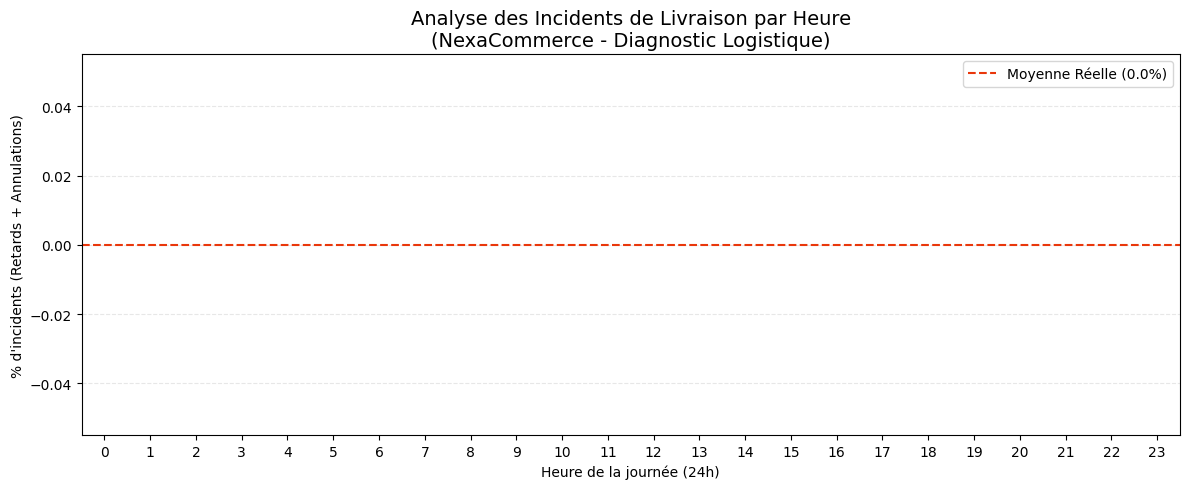

In [65]:

print(display(orders))


orders['is_problematic'] = orders['status'].isin(['late', 'cancelled'])

hourly_stats = orders.groupby('order_hour')['is_problematic'].agg(['count', 'mean']).reset_index()
hourly_stats.columns = ['heure', 'total_commandes', 'taux_retard']
hourly_stats['taux_retard_pct'] = hourly_stats['taux_retard'] * 100

print(hourly_stats)
# Moyenne
moyenne_globale_reelle = (orders['is_problematic'].sum() / len(orders)) * 100

plt.figure(figsize=(12, 5))


sns.barplot(data=hourly_stats, x='heure', y='taux_retard_pct', color='#3498db')

# Ligne moyenne
plt.axhline(y=moyenne_globale_reelle, color="#e9370b", linestyle='--', 
            label=f'Moyenne Réelle ({moyenne_globale_reelle:.1f}%)')

# Heure faible volume
for i, row in hourly_stats.iterrows():
    if row['total_commandes'] < 5: 
        plt.text(i, row['taux_retard_pct'] + 0.5, '!', color='red', ha='center', fontweight='bold')

plt.title("Analyse des Incidents de Livraison par Heure\n(NexaCommerce - Diagnostic Logistique)", fontsize=14)
plt.xlabel("Heure de la journée (24h)")
plt.ylabel("% d'incidents (Retards + Annulations)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Heure Jour qui ont le plus de retards

Une heatmap révèle immédiatement les zones de tension opérationnelle. Taux de retard parmis les livraisons.  

ValueError: zero-size array to reduction operation fmin which has no identity

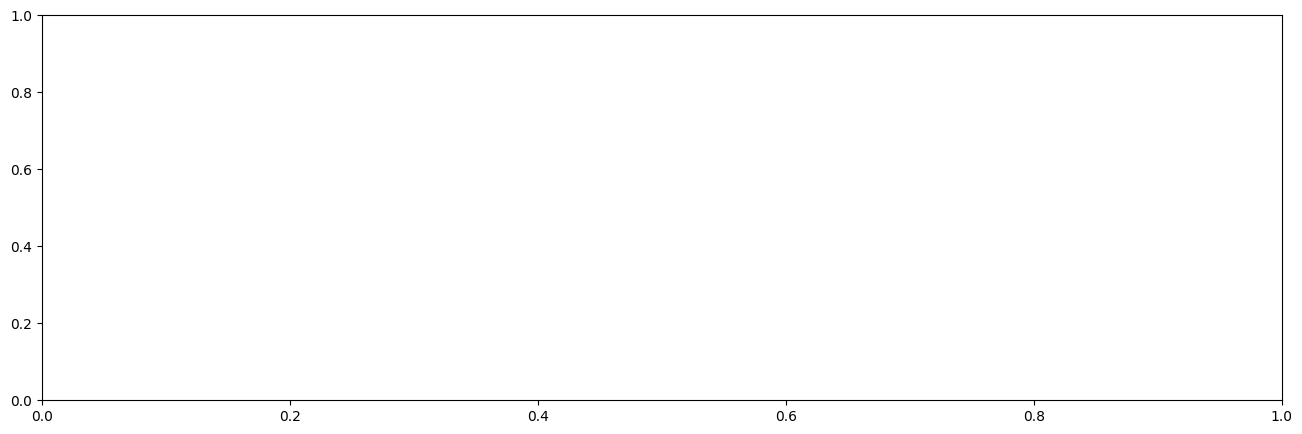

In [61]:
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday",
              "Friday",  "Saturday", "Sunday"]
dow_labels = ["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"]

status_reussis = ['delivered', 'late']
orders_valid = orders[orders['status'].isin(status_reussis)].copy()

heatmap_data = (
    orders_valid
    .groupby(["order_day_of_week", "order_hour"])["status"]
    .apply(lambda x: (x == "late").mean() * 100)
    .reset_index()
)

heatmap_data.columns = ["Jour", "Heure", "Taux_Retard"]

pivot = (
    heatmap_data
    .pivot(index="Jour", columns="Heure", values="Taux_Retard")
    .reindex(dow_order)    
)


fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    pivot,
    cmap="YlOrRd",
    annot=True,
    fmt=".0f",
    linewidths=0.3,
    linecolor="#E5E7EB",
    cbar_kws={"label": "Taux de retard (%)"},
    ax=ax,
    annot_kws={"size": 7},
)
ax.set_yticklabels(
    [dow_labels[dow_order.index(d)] for d in pivot.index],
    rotation=0, fontsize=9
)
ax.set_xticklabels(
    [f"{h}h" for h in pivot.columns],
    rotation=45, ha="right", fontsize=8
)
ax.set_xlabel("Heure de la commande")
ax.set_ylabel("Jour de la semaine")
ax.set_title(
   "Heatmap Taux de retard par Jour * Heure",
    fontweight="bold", pad=12
)

plt.tight_layout()
plt.show()

Nous remarquons que la journée de la semaine samedi à 4h à un taux de retard à 100 %, ainsi que les journée de Mardi à 4h et samedi à 22h qui ont les plus gros taux de retard

### Score des liveurs par ville

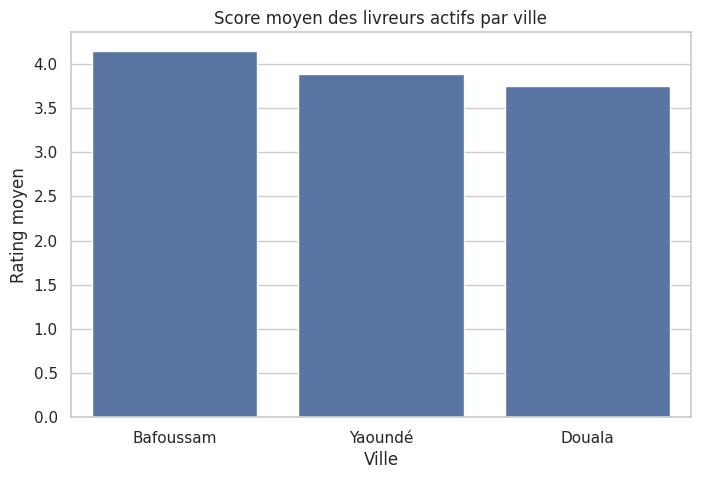

In [196]:
active_couriers = couriers[couriers["is_active"] == True].copy()
active_couriers.head()

active_couriers['city'] = active_couriers['city'].map(city_normalise)

active_courier_scores_by_city = (
    active_couriers.groupby("city")["rating"]
    .mean()
    .reset_index()
    .sort_values("rating", ascending=False)
)

active_courier_scores_by_city

plt.figure(figsize=(8, 5))
sns.barplot(
    data=active_courier_scores_by_city,
    x="city",
    y="rating"
)
plt.title("Score moyen des livreurs actifs par ville")
plt.xlabel("Ville")
fig.savefig("../reports/EDA/courier_actif.png", bbox_inches="tight", dpi=150)

plt.ylabel("Rating moyen")
plt.show()

#### Interprétation
Le graphique nous montre les villes dont les livreus actifs ont été les plus notés.  

  city_order  is_delivered  is_late  is_cancelled  is_in_progress  total
0  Bafoussam          1258      433           184              68   1943
1     Douala          4195     1395           606             226   6422
2    Yaoundé          2650      974           380             131   4135


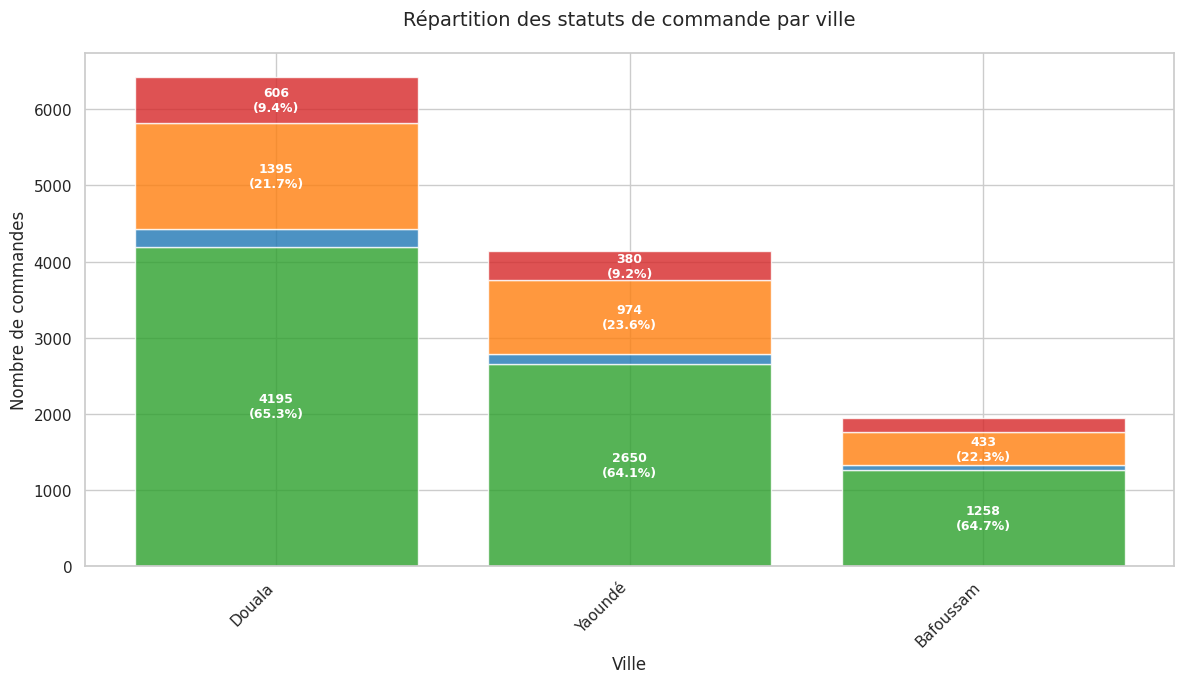

In [275]:

for status in ['delivered', 'late', 'cancelled', 'in_progress']:
    col_name = f"is_{status.replace(' ', '_')}"
    analysis[col_name] = (analysis['status'] == status).astype(int)

cols_to_sum = ['is_delivered', 'is_late', 'is_cancelled', 'is_in_progress']
agg = analysis.groupby('city_order')[cols_to_sum].sum().reset_index()
agg['total'] = agg[cols_to_sum].sum(axis=1)

print(agg)

for col in cols_to_sum:
    agg[col + '_pct'] = (agg[col] / agg['total']) * 100

agg = agg.sort_values('total', ascending=False).reset_index(drop=True)

# 5. Visualisation
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

plot_configs = [
    {'col': 'is_delivered', 'label': 'Livré', 'color': '#2ca02c'},
    {'col': 'is_in_progress', 'label': 'En cours', 'color': '#1f77b4'},
    {'col': 'is_late', 'label': 'En retard', 'color': '#ff7f0e'},
    {'col': 'is_cancelled', 'label': 'Annulé', 'color': '#d62728'}
]

bottom = pd.Series([0.0] * len(agg))

for config in plot_configs:
    plt.bar(agg['city_order'], agg[config['col']], bottom=bottom, 
            label=config['label'], color=config['color'], alpha=0.8)
    
    # Ajout des annotations au milieu de chaque segment
    for idx, row in agg.iterrows():
        val = row[config['col']]
        pct = row[config['col'] + '_pct']
        if val > (agg['total'].max() * 0.05):  # On n'affiche que si le segment est assez large
            plt.text(idx, bottom[idx] + val/2, f"{int(val)}\n({pct:.1f}%)", 
                     ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    
    bottom += agg[config['col']]

plt.xticks(rotation=45, ha='right')
plt.xlabel("Ville")
plt.ylabel("Nombre de commandes")
plt.title("Répartition des statuts de commande par ville", fontsize=14, pad=20)
plt.tight_layout()
plt.show()


#### Interprétation
Le graphique met en évidence les commandes, taux de commandes, pourcentage de commande dans une ville. c'est à dire si Douala traite le plus gros volume, le taux de commandes 'en_retard' y est proportionnellement plus élevé qu'à Yaoundé. Ceci nous apprends que le retard sur les commandes ne sont dû au faite qu'il puisse avoir beauoup de commande dans la ville, mais plûtot au niveau de la densité de la population.

### Repartition globale des status de commandes  

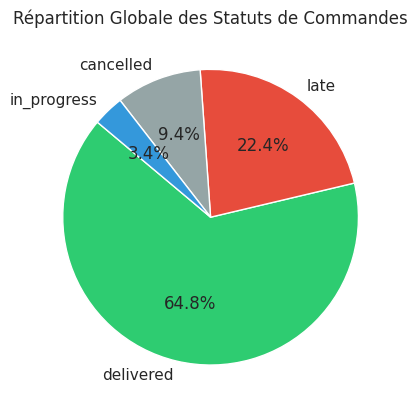

In [195]:

status_counts = orders['status'].value_counts()
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=140, 
        colors=['#2ecc71', '#e74c3c', '#95a5a6', '#3498db'])
fig.savefig("../reports/EDA/global_status.png", bbox_inches="tight", dpi=150)
plt.title("Répartition Globale des Statuts de Commandes")
plt.show()

#### interpretaion
Avec ce graphique nous pouvons voir que nous avons 9.4 % des commandes qui sont annulées.   

#### KPI des données de Nexacommerce

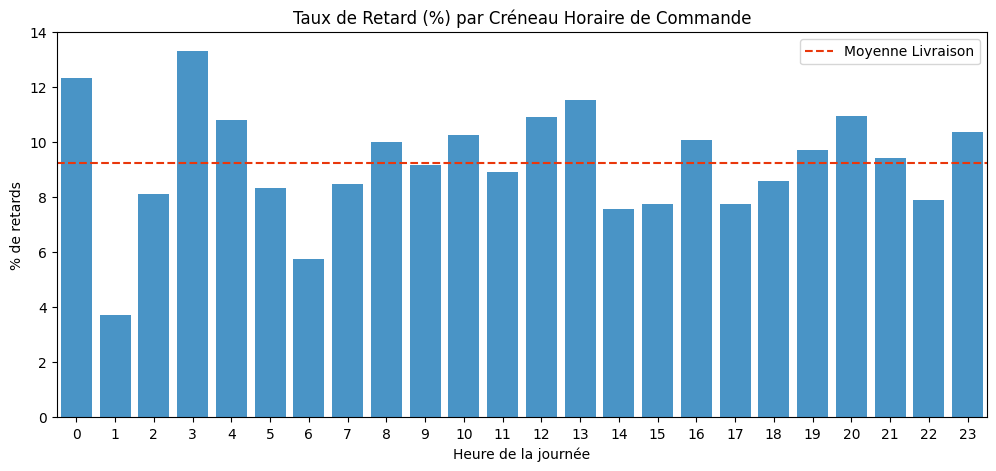

In [71]:

if 'is_delayed' not in orders.columns:
    
    orders['is_delayed'] = (orders['status'] == 'late') 

hourly_retard = orders.groupby('order_hour')['is_delayed' if 'is_delayed' in orders.columns else 'status'].apply(
    lambda x: (x == 'cancelled').mean() if x.name == 'status' else x.mean()
)

# Recalcul plus propre directement
hourly_stats = orders.groupby('order_hour').apply(
    lambda x: pd.Series({
        'total': len(x),
        'retards': (x['status'] == 'cancelled').sum()
    })
)
hourly_stats['taux_retard'] = (hourly_stats['retards'] / hourly_stats['total']) * 100

plt.figure(figsize=(12, 5))
sns.barplot(x=hourly_stats.index, y=hourly_stats['taux_retard'], color='#3498db')
plt.title("Taux de Retard (%) par Créneau Horaire de Commande")
plt.xlabel("Heure de la journée")
plt.ylabel("% de retards")
plt.axhline(y=hourly_stats['taux_retard'].mean(), color="#e9370b", linestyle='--', label='Moyenne Livraison')
plt.legend()
plt.show()

In [254]:
df_merged = order_items.merge(orders[['order_id', 'status']], on='order_id', how='left')
df_merged['product_category'] = df_merged['product_category'].str.capitalize()


df_merged['status'] = df_merged['status'].fillna('unknown').str.lower()


ca_total = df_merged.groupby('product_category')['line_total_xaf'].sum()


status_valides = ['delivered', 'late']
df_secure = df_merged[df_merged['status'].isin(status_valides)]
ca_secure = df_secure.groupby('product_category')['line_total_xaf'].sum()

# Df comparaison
ca_comparison = pd.DataFrame({
    'Global': ca_total,
    'Sécurisé': ca_secure
}).fillna(0).sort_values('Global', ascending=False).head(10)

print(ca_comparison)

ca_plot_data = ca_comparison.reset_index().melt(id_vars='product_category', var_name='Type CA', value_name='Montant')



fig = px.bar(
    ca_plot_data, 
    y="product_category", 
    x="Montant", 
    color="Type CA",
    barmode="group",
    orientation='h',
    title="Analyse Comparative du Chiffre d'Affaires par Catégorie",
    labels={"Montant": "Chiffre d'Affaires (FCFA)", "product_category": "Catégorie"},
    color_discrete_map={"Global": "#B0BEC5", "Sécurisé": "#2E7D32"},
    template="plotly_white" 
)

# Amélioration de la mise en page
fig.update_layout(
    yaxis={'categoryorder':'total ascending'}, 
    hovermode="y unified"
)
fig.show()

                      Global    Sécurisé
product_category                        
Vêtements         67699145.0  59439162.0
Électronique      66590450.0  58239716.0
Pharmacie         30152434.0  26632528.0
Restauration      28493643.0  25014283.0
Cosmétiques       16257979.0  14221675.0
Épicerie          16076910.0  13888734.0
Produits frais    13311154.0  11594008.0
Boissons          10755099.0   9357742.0
Hygiène            9754408.0   8538202.0
Papeterie          7849212.0   6853057.0


### KPI Orders 

In [249]:

total_orders = len(orders)
success_rate = (orders['status'].isin(['delivered', 'late'])).mean() * 100


avg_order_value = orders[orders['status'].isin(['delivered', 'late'])]['total_amount_xaf'].mean()


city_rev = orders.groupby('city')['total_amount_xaf'].sum().sort_values(ascending=False).head(5)


fig = make_subplots(
    rows=2, cols=2,
    specs=[[{'type': 'indicator'}, {'type': 'pie'}],
           [{'type': 'bar'}, {'type': 'heatmap'}]],
    subplot_titles=("Performance Financière", "Répartition des Commandes",
                    "CA par Ville (Top 5)", "Zones de Risque Logistique (Retards)")
)


fig.add_trace(go.Indicator(
    mode="number+delta",
    value=avg_order_value,
    number={'suffix': " XAF", 'font': {'size': 20}},
    title={"text": "Panier Moyen (AOV)"},
    domain={'x': [0, 0.5], 'y': [0.6, 1]}
), row=1, col=1)


status_counts = orders['status'].value_counts()
fig.add_trace(go.Pie(
    labels=status_counts.index,
    values=status_counts.values,
    hole=.4,
    marker=dict(colors=['#2E7D32', '#F44336', '#FF9800', '#2196F3'])
), row=1, col=2)



fig.add_trace(go.Bar(
    x=city_rev.index,
    y=city_rev.values,
    marker_color='#666BBD',
    name="CA"
), row=2, col=1)



heatmap_data = orders.groupby(['order_day_of_week', 'order_hour'])['status'].apply(
    lambda x: (x == 'late').mean() * 100).reset_index()

fig.add_trace(go.Heatmap(
    z=heatmap_data['status'],
    x=heatmap_data['order_hour'],
    y=heatmap_data['order_day_of_week'],
    colorscale='Reds',
    showscale=False
), row=2, col=2)


fig.update_layout(
    title_text="TABLEAU DE BORD DE PILOTAGE - NEXACOMMERCE 2026",
    title_font_size=24,
    template="plotly_white",
    height=900,
    showlegend=False
)

fig.show()

## Insight pour la direction

Ici nous identifions les idées pour aider à améliorer le service marketing et financier de nexacommerce.

1. *L'activité à certains heure de la journée.*

Est ce que le volume de commandes est complètement homogène sur le temps de la journée, mais aussi est ce que le faite de se faire livrér a certains heure de la journée pourrais avoir un impact sur le retard d'une commande. 
    Il faudrais adpater la logistique en fonction

2. *Activité sur les categories des produits*

Quelle sont les produits qui sont les plus annulés ? ex: La categorie Épicerie represente quel pourcentage dans le taux d'annulation des commandes ? L'annulation d'une commande depends t-il de son produit ? Il faudrais pouvoir elargir le réseaux pour reduire le temps d'attente pour un produit qu'on peut possiblement trouvé à côté.

3. *Fidélisation et clientelle*

Est ce que les clients les plus fidèle sont plus servis que les autres ? Est ce que les clients premium avec un fort panier moyen ont un privilège par rapport au autre client ? Est ce qu'il exite une corrélation entre le loyalty_score d'un client et son pannier moyen ? Il faudrais que les clients les plus fidèles soit les plus satisfait pour augmenter le panier moyen de celui ci et recevoir d'autre client. 

4. *Annulation de commandes*

Est ce que les annulations de commandes sont dûe au faites de ne pas avoir de la monaie ? Alors pour cela il faudrais encourager les méthodes de paiement mobiles pour éviter les annulations. 

5. *Performance des liveurs*

Les livreurs les plus performant recoivent t-il un meilleur salaire ? Avons nous beaucoup de temps de livraison qui sont en dehors des outliers ont un impacte sur la finance ?  Pour les livreurs les plus prompts il faudrais pouvoir leur fournir une récompenses.

## Exécutive Summary

Cette analyse vise à évaluer la performance opérationnelle et commerciale de NexaCommerce à partir des données de commandes, clients et livreurs, afin d’identifier les leviers d’optimisation logistique et de croissance de l'entreprise.
L'analyse de plus de 5 ans de données opérationnelles confirme une trajectoire de croissance solide pour NexaCommerce puis une chute brutale vers février 2025. 
Cependant, l'histoire des données révèle des frictions logistiques critiques à Yaoundé et lors des pics d'activité qui freinent la rentabilité et la fidélisation client du côté de yaoundé. Mais par ailleur nous avons aussi nombre de retard dans la ville de douala  qui est plus ou moins pareille que le pourcentage de retard dans la ville de Yaoundé ce qui prouve que le retard des commandes ne dépends pas de la quantité de commande mais de la logistique.
La donnée nous raconte alors : 
- Résoudre les problèmes de logistique dans la ville de yaoundé.

- Douala est le principal levier de croissance avec un fort impact.   

- La qualité de données (ex: numero télephone table customers, ainsi que les montants) est un problème dans les analyses.

- Les  retards repete est un soucis pour l'expérience client. 

Les recomandations proposez par rapport à ça serais : 

-  Prioriser la logistique à yaoundé.

-  Prioriser la logistique à certaines heure de la journée 

-  Mettre en place un suivi des client premium 